### 1. Importing the libraries

In [1]:
import os, random
from pathlib import Path
from PIL import Image

import matplotlib.pyplot as plt
from typing import List

from tqdm.auto import tqdm
from timeit import default_timer as timer

import torch, torchinfo
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import functional as F

%matplotlib inline

In [2]:
# Setting up the device for model training:
if torch.backends.mps.is_available():
    device = "mps"
elif torch.backends.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"{device=}")

device='mps'


In [3]:
# Setting up common variables and walking through the directory
BATCH_SIZE = 64
NUM_WORKERS = os.cpu_count()

data_path = Path("dataset/")
image_path = data_path
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")
walk_through_dir(data_path)

There are 3 directories and 0 images in 'dataset'
There are 2 directories and 0 images in 'dataset/test'
There are 0 directories and 15 images in 'dataset/test/PNEUMONIA'
There are 0 directories and 15 images in 'dataset/test/NORMAL'
There are 2 directories and 0 images in 'dataset/train'
There are 0 directories and 3400 images in 'dataset/train/PNEUMONIA'
There are 0 directories and 3400 images in 'dataset/train/NORMAL'
There are 2 directories and 0 images in 'dataset/val'
There are 0 directories and 850 images in 'dataset/val/PNEUMONIA'
There are 0 directories and 850 images in 'dataset/val/NORMAL'


In [4]:
# Setting up Train, Validation and Test paths
train_dir = "dataset/train"
val_dir = "dataset/val"
test_dir = "dataset/test"

### 2. Visualization

Random image path: dataset/train/NORMAL/NORMAL2-IM-0979-0001_aug_2022.jpg
Image class: NORMAL
Image height: 1079
Image width: 1416


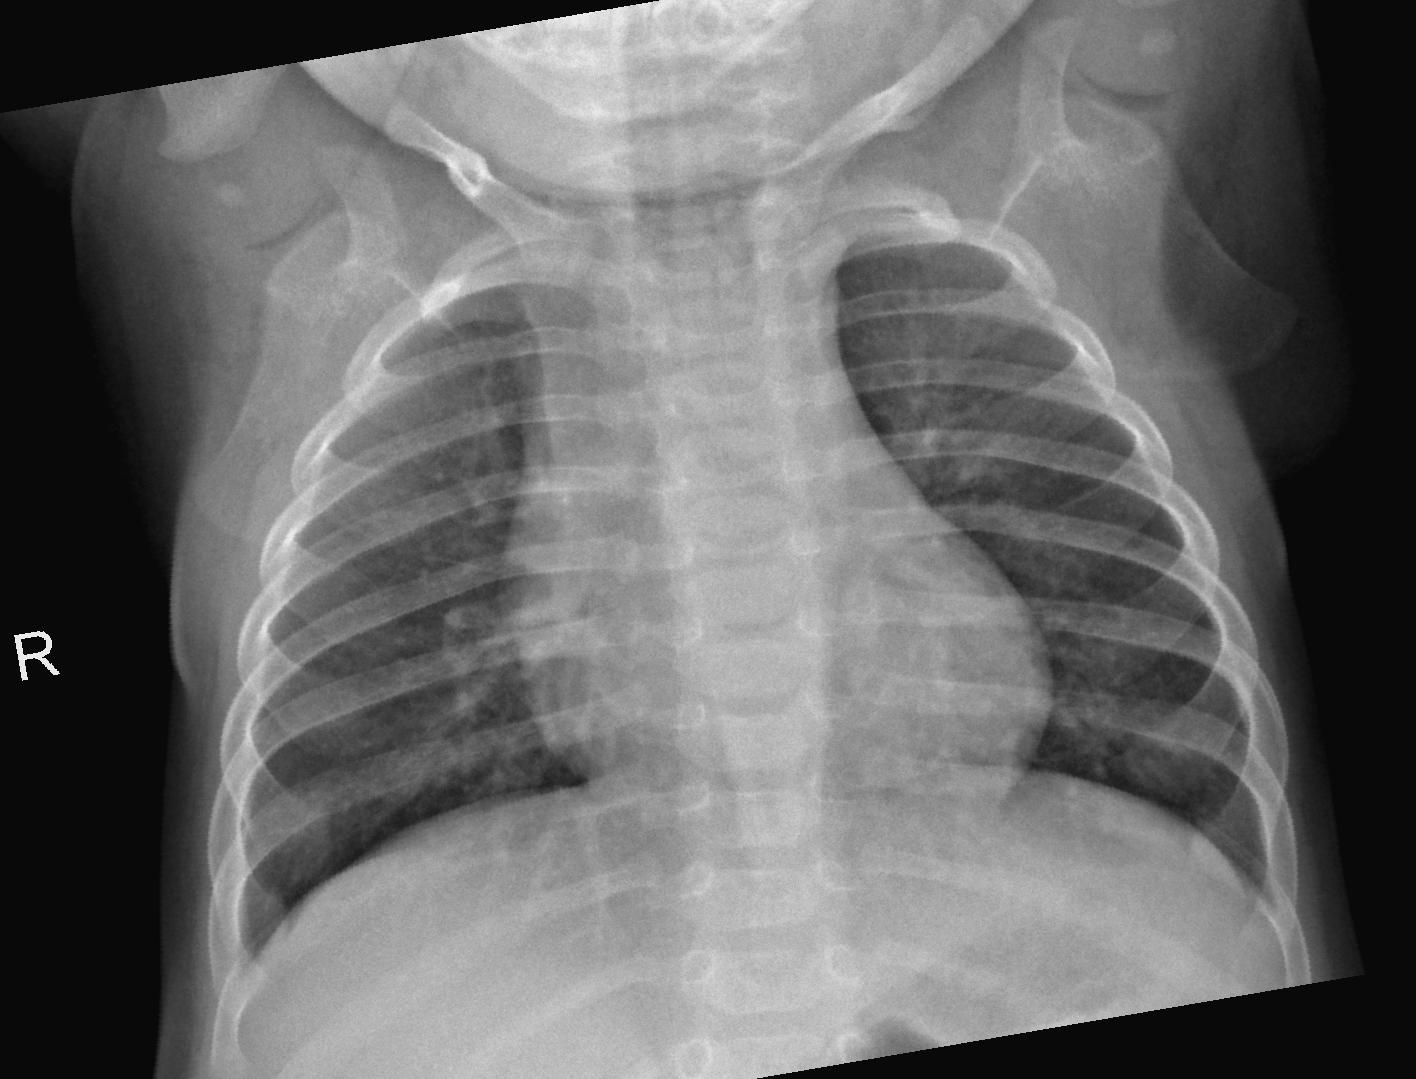

In [5]:
# Visualizing random images
random.seed(14)

# Getting all the image paths
image_path_list = [im for im in image_path.glob("*/*/*") if im.suffix.lower() in [".jpg","jpeg"]]

# Getting random image path
random_image_path = random.choice(image_path_list)

# Getting image class from path name
image_class = random_image_path.parent.stem

# Opening Image
img = Image.open(random_image_path)

# Printing metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

In [6]:
# Transforming the image
train_transforms = transforms.Compose([
    transforms.Resize(size=(128,128)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31), # Applying random transformations from a wide pool available
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor()
])

val_transforms = transforms.Compose([
    transforms.Resize(size=(128,128)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(128,128)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor()
])

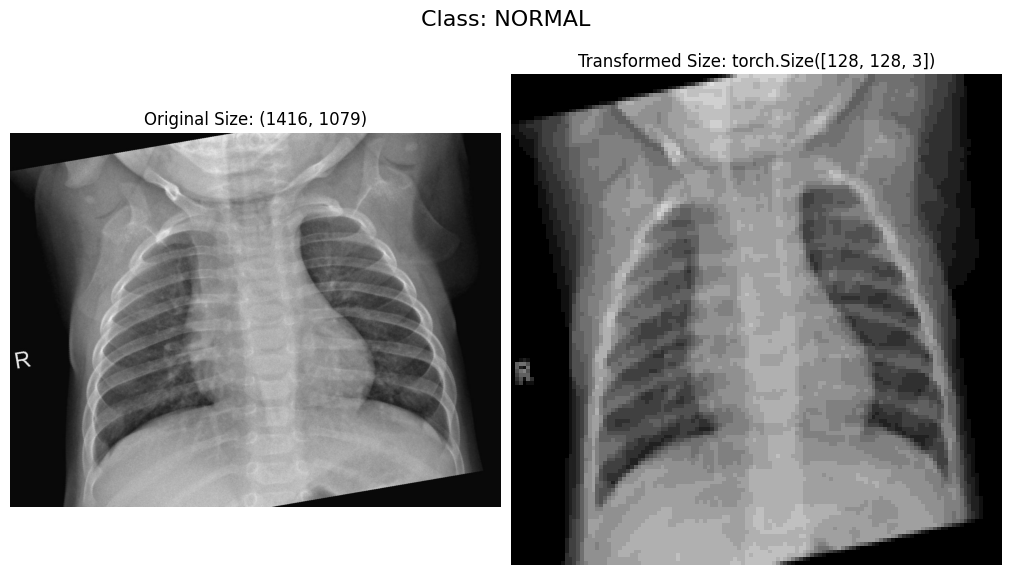

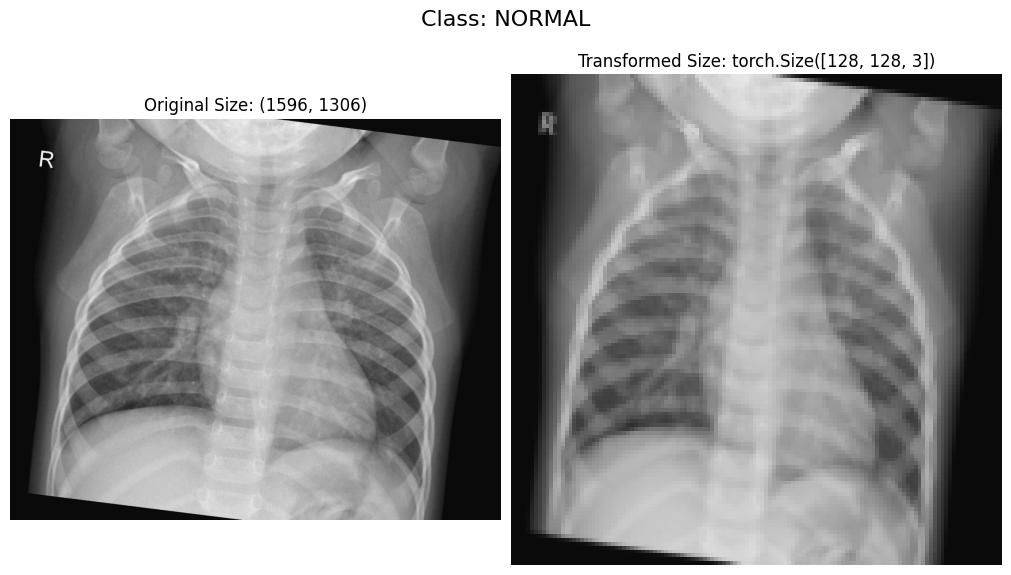

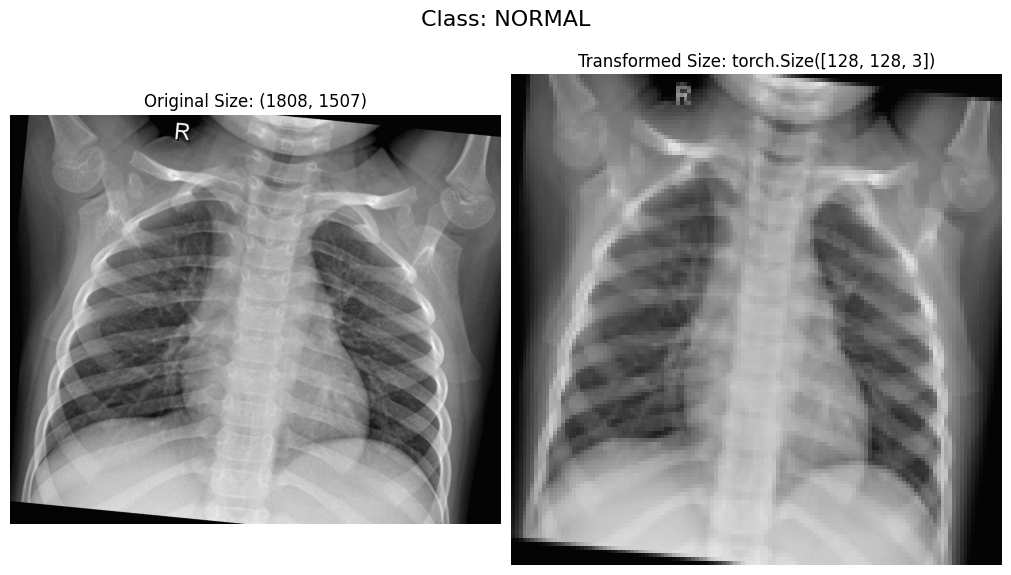

In [7]:
def plot_transformed_images(image_paths, transform, n=3, seed=14):
    # Plotting some random images and the transformed versions of those as well
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1,2, figsize=(10,6), constrained_layout=True)
            ax[0].imshow(f)
            ax[0].set_title(f"Original Size: {f.size}")
            ax[0].axis("off")
    
            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed Size: {transformed_image.size()}")
            ax[1].axis("off")
    
            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths=image_path_list, transform=train_transforms)

### 3. Setting up data loaders

In [8]:
# Loading the data using ImageFolder since the directory is already structured
train_data = datasets.ImageFolder(root=train_dir,transform=train_transforms,target_transform=None)
val_data = datasets.ImageFolder(root=val_dir,transform=val_transforms)
test_data = datasets.ImageFolder(root=test_dir,transform=test_transforms)

print(f"Train data: \n {train_data} \n\n Val data: \n {val_data} \n\n Test data: \n {test_data} \n")

Train data: 
 Dataset ImageFolder
    Number of datapoints: 6800
    Root location: dataset/train
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               Lambda()
               ToTensor()
           ) 

 Val data: 
 Dataset ImageFolder
    Number of datapoints: 1700
    Root location: dataset/val
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               Lambda()
               ToTensor()
           ) 

 Test data: 
 Dataset ImageFolder
    Number of datapoints: 30
    Root location: dataset/test
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               Lambda()
               ToTensor()
           ) 



In [9]:
# Printing class names and class labels
class_names = train_data.classes
print(f"{class_names=}")

class_dict = train_data.class_to_idx
print(f"{class_dict=}")

# Count of Train, Val, Test data points
print(f"\nTrain set: {len(train_data)}")
print(f"Val set: {len(val_data)}")
print(f"Test set: {len(test_data)}")

class_names=['NORMAL', 'PNEUMONIA']
class_dict={'NORMAL': 0, 'PNEUMONIA': 1}

Train set: 6800
Val set: 1700
Test set: 30


In [10]:
# Validation of conversion of image to tensors and labels
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor: \n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor: 
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.1137, 0.1216, 0.1176,  ..., 0.1333, 0.1333, 0.1255],
         [0.1176, 0.1216, 0.1176,  ..., 0.1333, 0.1333, 0.1216],
         [0.1176, 0.1216, 0.1176,  ..., 0.1333, 0.1294, 0.1216]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.1137, 0.1216, 0.1176,  ..., 0.1333, 0.1333, 0.1255],
         [0.1176, 0.1216, 0.1176,  ..., 0.1333, 0.1333, 0.1216],
         [0.1176, 0.1216, 0.1176,  ..., 0.1333, 0.1294, 0.1216]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0

Original shape: torch.Size([3, 128, 128]) -> [color_channels, height, width]
Image permute shape: torch.Size([128, 128, 3]) -> [height, width, color_channels]


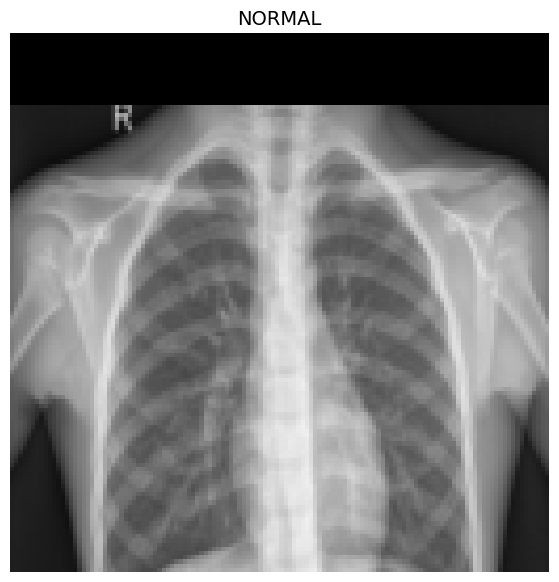

In [11]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);

In [12]:
# Creating train, validation, and test data loaders
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=val_data, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
train_dataloader, val_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x11fd46e40>,
 <torch.utils.data.dataloader.DataLoader at 0x11fe8a990>)

In [13]:
img, label = next(iter(train_dataloader))
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([64, 3, 128, 128]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([64])


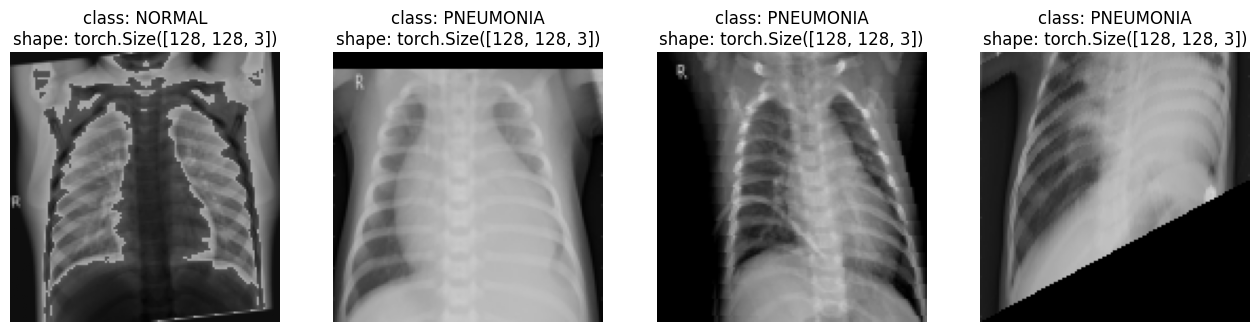

In [15]:
# Displaying random images
def display_random_images(dataset: torch.utils.data.dataset.Dataset, classes: List[str]=None, 
                          n: int=10, display_shape: bool=True, seed: int=14):
    if n>10:
        n=10
        display_shape=False

    if seed:
        random.seed(seed)

    random_samples_idx = random.sample(range(len(dataset)), k=n)

    plt.figure(figsize=(16,8))

    for i, target_sample in enumerate(random_samples_idx):
        target_image, target_label = dataset[target_sample][0], dataset[target_sample][1]
        target_image_adjust = target_image.permute(1,2,0)
        plt.subplot(1,n,i+1)
        plt.imshow(target_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[target_label]}"
            if display_shape:
                title = title + f"\nshape: {target_image_adjust.shape}"
        plt.title(title)

display_random_images(train_data, n=4, classes=class_names, seed=14)

### 4. Defining our TinyVGG model

In [16]:
# Using a TinyVGG model
class TinyVGG(nn.Module):
    def __init__(self, input_shape, output_shape):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels=input_shape, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(32, 64, 3, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, 3, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.features(x)
        x = self.classifier(x)
        return x

torch.manual_seed(14)
model_tinyvgg = TinyVGG(input_shape=3, output_shape=len(train_data.classes)).to(device)
print(f"Total trainable parameters: {sum([p.numel() for p in model_tinyvgg.parameters() if p.requires_grad])}")
model_tinyvgg

Total trainable parameters: 148450


TinyVGG(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (15): BatchNorm2d(128, eps=1e-05, momentu

In [17]:
img_batch, label_batch = next(iter(train_dataloader))
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]

print(f"Single image shape: {img_single.shape}")

model_tinyvgg.eval()
with torch.inference_mode():
    pred = model_tinyvgg(img_single.to(device))

print(f"Output logits: {pred}")
print(f"Output prediction probabilities: {torch.softmax(pred, dim=1)}")
print(f"Output prediction label: {torch.argmax(torch.softmax(pred, dim=1))}")
print(f"Actual Label: {label_single}")

# Since the weights are randomly initialized and first guess should be equally likely for all classes

Single image shape: torch.Size([1, 3, 128, 128])
Output logits: tensor([[0.0092, 0.0662]], device='mps:0')
Output prediction probabilities: tensor([[0.4858, 0.5142]], device='mps:0')
Output prediction label: 1
Actual Label: 1


In [18]:
def train_step(model, dataloader, loss_fn, optimizer):
    # Putting the model in training mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Zeroing gradients
        optimizer.zero_grad()

        # 4. Backward pass
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class==y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model, dataloader, loss_fn):
    # Putting the model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turning on inference context manager
    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # 3. Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels==y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs):
    # 1. Create an empty results dictionary
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 2. Initializing a loss value
    best_val_loss = float("inf")

    # 3. Loop through training and testing steps for a number of eppochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,dataloader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer)
        
        test_loss, test_acc = test_step(model=model,dataloader=test_dataloader,loss_fn=loss_fn)

        # Saving best model until now
        if test_loss < best_val_loss:
            best_val_loss = test_loss
            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss,
                "hidden_units": 10,
                "input_shape": 3
            }, "best_model.pth")
            print("Saved new best model!")

        # Printing metrics for each epoch
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # Updating results dictionary
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results

### 5. Training our model

In [20]:
# Setting random seeds
torch.manual_seed(14)
torch.mps.manual_seed(14)

# Set number of epochs
NUM_EPOCHS = 10

# Re-Create an instance of TinyVGG
model_tinyvgg = TinyVGG(input_shape=3, output_shape=len(train_data.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_tinyvgg.parameters(), lr=1e-3)

start_time = timer()

# Training
model_tinyvgg_results = train(model=model_tinyvgg, train_dataloader=train_dataloader, 
                              test_dataloader=val_dataloader, optimizer=optimizer, 
                              loss_fn=loss_fn, epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Saved new best model!
Epoch: 1 | train_loss: 0.4287 | train_acc: 0.8122 | test_loss: 0.2879 | test_acc: 0.9183
Saved new best model!
Epoch: 2 | train_loss: 0.3184 | train_acc: 0.8684 | test_loss: 0.2156 | test_acc: 0.9128
Saved new best model!
Epoch: 3 | train_loss: 0.2847 | train_acc: 0.8826 | test_loss: 0.2146 | test_acc: 0.9196
Epoch: 4 | train_loss: 0.2626 | train_acc: 0.8931 | test_loss: 0.2690 | test_acc: 0.8993
Saved new best model!
Epoch: 5 | train_loss: 0.2323 | train_acc: 0.9065 | test_loss: 0.2070 | test_acc: 0.9201
Epoch: 6 | train_loss: 0.2258 | train_acc: 0.9112 | test_loss: 0.2172 | test_acc: 0.9219
Saved new best model!
Epoch: 7 | train_loss: 0.2243 | train_acc: 0.9105 | test_loss: 0.2042 | test_acc: 0.9184
Saved new best model!
Epoch: 8 | train_loss: 0.1975 | train_acc: 0.9244 | test_loss: 0.1389 | test_acc: 0.9528
Saved new best model!
Epoch: 9 | train_loss: 0.1970 | train_acc: 0.9206 | test_loss: 0.1265 | test_acc: 0.9544
Epoch: 10 | train_loss: 0.1940 | train_acc: 0

### 6. Plotting captured metrics

In [21]:
def plot_loss_curves(results):
    
    # Get the loss values of the results dictionary
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    # Get the accuracy values of the results dictionary
    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    # Check the number of epochs
    epochs = range(len(results["train_loss"]))

    # Setup a plot
    plt.figure(figsize=(15,7))

    # Plot loss
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend();

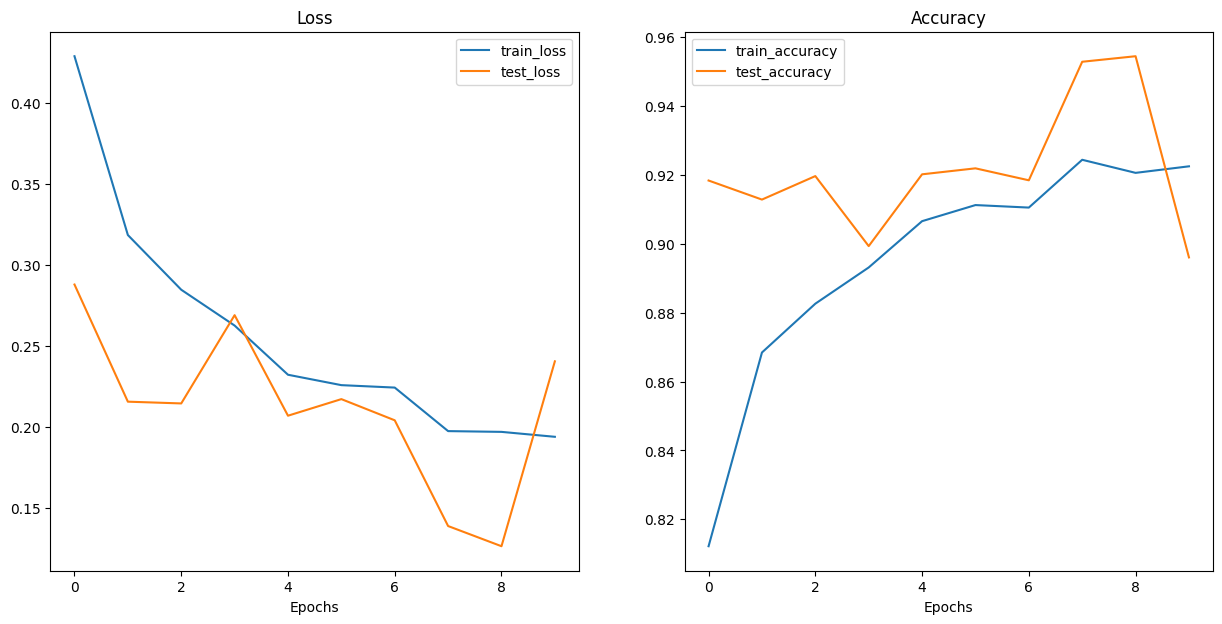

In [22]:
plot_loss_curves(model_tinyvgg_results)

### 7. Loading our best model and finally testing on test set

In [23]:
# loading our best model
model_tinyvgg.load_state_dict(torch.load("best_model.pth")['model_state_dict'])

<All keys matched successfully>

In [24]:
test_loss, test_acc = test_step(model=model_tinyvgg, dataloader=test_dataloader, loss_fn=loss_fn)
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Accuracy: 0.9000
